In [22]:
import os
import shutil
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix

In [15]:
import os

source_dir = '/content/drive/MyDrive/MSIB Batch 6 - Data Science/Deep Learning /Task 2/dataset'

# Check source directory contents
print("Source directory contents:")
for root, dirs, files in os.walk(source_dir):
    print(root, len(files))

normal_dir = '/content/drive/MyDrive/MSIB Batch 6 - Data Science/Deep Learning /Task 2/dataset/NORMAL'
covid_dir = '/content/drive/MyDrive/MSIB Batch 6 - Data Science/Deep Learning /Task 2/dataset/COVID'

print(f"Number of images in NORMAL: {len(os.listdir(normal_dir))}")
print(f"Number of images in COVID: {len(os.listdir(covid_dir))}")

Source directory contents:
/content/drive/MyDrive/MSIB Batch 6 - Data Science/Deep Learning /Task 2/dataset 0
/content/drive/MyDrive/MSIB Batch 6 - Data Science/Deep Learning /Task 2/dataset/COVID 1626
/content/drive/MyDrive/MSIB Batch 6 - Data Science/Deep Learning /Task 2/dataset/NORMAL 1802
/content/drive/MyDrive/MSIB Batch 6 - Data Science/Deep Learning /Task 2/dataset/train 0
/content/drive/MyDrive/MSIB Batch 6 - Data Science/Deep Learning /Task 2/dataset/train/COVID 1300
/content/drive/MyDrive/MSIB Batch 6 - Data Science/Deep Learning /Task 2/dataset/train/NORMAL 1441
/content/drive/MyDrive/MSIB Batch 6 - Data Science/Deep Learning /Task 2/dataset/test 0
/content/drive/MyDrive/MSIB Batch 6 - Data Science/Deep Learning /Task 2/dataset/test/COVID 326
/content/drive/MyDrive/MSIB Batch 6 - Data Science/Deep Learning /Task 2/dataset/test/NORMAL 361
Number of images in NORMAL: 1802
Number of images in COVID: 1626


#Membangun model AlexNet

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Definisikan model AlexNet
model_alexnet = Sequential([
    Conv2D(96, (11, 11), strides=4, padding='same', activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D((3, 3), strides=2),

    Conv2D(256, (5, 5), padding='same', activation='relu'),
    MaxPooling2D((3, 3), strides=2),

    Conv2D(384, (3, 3), padding='same', activation='relu'),
    Conv2D(384, (3, 3), padding='same', activation='relu'),
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((3, 3), strides=2),

    Flatten(),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Kompilasi model
model_alexnet.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Tampilkan arsitektur model
model_alexnet.summary()


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_10 (Conv2D)          (None, 56, 56, 96)        34944     
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 27, 27, 96)        0         
 g2D)                                                            
                                                                 
 conv2d_11 (Conv2D)          (None, 27, 27, 256)       614656    
                                                                 
 max_pooling2d_7 (MaxPoolin  (None, 13, 13, 256)       0         
 g2D)                                                            
                                                                 
 conv2d_12 (Conv2D)          (None, 13, 13, 384)       885120    
                                                                 
 conv2d_13 (Conv2D)          (None, 13, 13, 384)      

In [20]:
# Data generators
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/MSIB Batch 6 - Data Science/Deep Learning /Task 2/dataset/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/MSIB Batch 6 - Data Science/Deep Learning /Task 2/dataset/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 2741 images belonging to 2 classes.
Found 687 images belonging to 2 classes.


#Melatih Model

In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Definisikan callback EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

# Definisikan model AlexNet
def create_alexnet(input_shape=(224, 224, 3), num_classes=2):
    model = Sequential()

    # 1st Convolutional Layer
    model.add(Conv2D(filters=96, input_shape=input_shape, kernel_size=(11,11), strides=(4,4), padding='valid', activation='relu'))
    model.add(MaxPooling2D(pool_size=(3,3), strides=(2,2), padding='valid'))

    # 2nd Convolutional Layer
    model.add(Conv2D(filters=256, kernel_size=(5,5), strides=(1,1), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(3,3), strides=(2,2), padding='valid'))

    # 3rd Convolutional Layer
    model.add(Conv2D(filters=384, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu'))

    # 4th Convolutional Layer
    model.add(Conv2D(filters=384, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu'))

    # 5th Convolutional Layer
    model.add(Conv2D(filters=256, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(3,3), strides=(2,2), padding='valid'))

    # Passing it to a Fully Connected layer
    model.add(Flatten())

    # 1st Fully Connected Layer
    model.add(Dense(4096, activation='relu'))
    model.add(Dropout(0.5))

    # 2nd Fully Connected Layer
    model.add(Dense(4096, activation='relu'))
    model.add(Dropout(0.5))

    # Output Layer
    model.add(Dense(num_classes, activation='softmax'))

    return model

# Create the model
model_alexnet = create_alexnet()

# Compile the model
model_alexnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Data generators
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/MSIB Batch 6 - Data Science/Deep Learning /Task 2/dataset/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/MSIB Batch 6 - Data Science/Deep Learning /Task 2/dataset/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# Melatih model dengan early stopping yang memiliki patience 50
history_alexnet = model_alexnet.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    callbacks=[early_stopping]
)

# Evaluasi model
scores = model_alexnet.evaluate(test_generator)
print(f"Test Accuracy: {scores[1]*100:.2f}%")

# Save the model and history
model_alexnet.save('alexnet_model.h5')
import pickle
with open('alexnet_history.pkl', 'wb') as file_pi:
    pickle.dump(history_alexnet.history, file_pi)


Found 2741 images belonging to 2 classes.
Found 687 images belonging to 2 classes.
Epoch 1/20
86/86 [==============================] - 554s 6s/step - loss: 0.6906 - accuracy: 0.6315 - val_loss: 0.3927 - val_accuracy: 0.8661
Epoch 2/20
86/86 [==============================] - 18s 211ms/step - loss: 0.2527 - accuracy: 0.9248 - val_loss: 0.3751 - val_accuracy: 0.8996
Epoch 3/20
86/86 [==============================] - 18s 210ms/step - loss: 0.1873 - accuracy: 0.9325 - val_loss: 0.0912 - val_accuracy: 0.9709
Epoch 4/20
86/86 [==============================] - 20s 229ms/step - loss: 0.1139 - accuracy: 0.9639 - val_loss: 0.0799 - val_accuracy: 0.9723
Epoch 5/20
86/86 [==============================] - 20s 227ms/step - loss: 0.0993 - accuracy: 0.9704 - val_loss: 0.0872 - val_accuracy: 0.9694
Epoch 6/20
86/86 [==============================] - 18s 208ms/step - loss: 0.0927 - accuracy: 0.9653 - val_loss: 0.0880 - val_accuracy: 0.9665
Epoch 7/20
86/86 [==============================] - 19s 227ms

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


#Plotting Curves

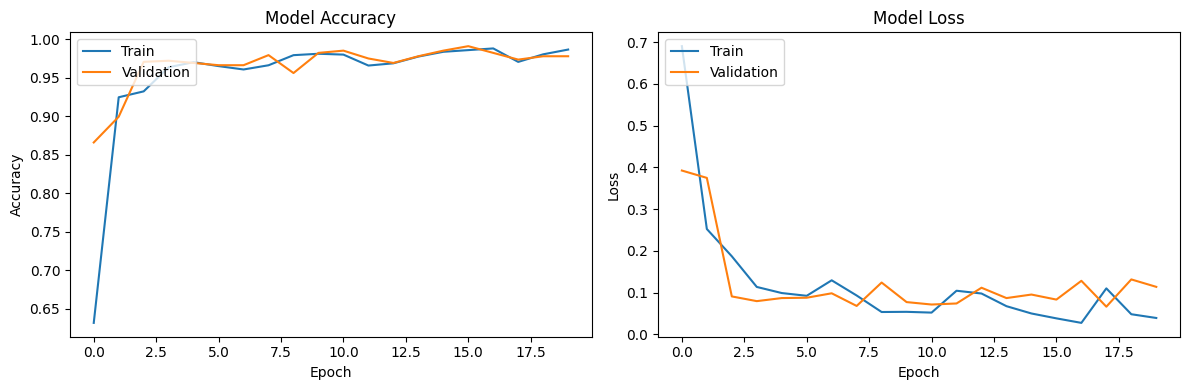

In [25]:
import matplotlib.pyplot as plt

# Fungsi untuk memplotting kurva learning
def plot_learning_curves(history):
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.tight_layout()
    plt.show()

# Panggil fungsi untuk memplotting kurva learning
plot_learning_curves(history_alexnet)